# Predicting Emergency Department Crowding: A Markov Chain Model of Hourly NEDOCS States

**Author:** Alexander Van Baelen   
**Project Type:** Healthcare Analytics / Predictive Modeling  
**Technologies:** Python, Pandas, NumPy, Markov Chains, Statistical Evaluation  
**Project Date:** April 2025

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, brier_score_loss,confusion_matrix
from sklearn.preprocessing import label_binarize
from typing import List, Dict
from collections import defaultdict
import holidays
from tqdm import tqdm
import ast


## Modeling Functions
### Data Preparation

In [4]:
def load_and_preprocess_nedocs(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath, parse_dates=["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)

    # NEDOCS binning
    def bin_nedocs(score):
        if -100 <= score <= 20:
            return "Not Busy"
        elif 21 <= score <= 60:
            return "Busy"
        elif 61 <= score <= 100:
            return "Extremely Busy"
        elif 101 <= score <= 140:
            return "Overcrowded"
        elif 141 <= score <= 180:
            return "Severe"
        else:
            return "Critical"

    # Apply binning
    df["state"] = df["nedocs_score"].apply(bin_nedocs)

    # Time features
    df["hour"] = df["timestamp"].dt.hour
    df["day_of_week"] = df["timestamp"].dt.dayofweek  # 0 = Monday
    df["iso_week"] = df["timestamp"].dt.isocalendar().week
    df["iso_year"] = df["timestamp"].dt.isocalendar().year
    df["day_of_year"] = df["timestamp"].dt.dayofyear
    df["month"] = df["timestamp"].dt.month
    df["year"] = df["timestamp"].dt.year
    df["is_weekend"] = df["day_of_week"] >= 5

    # Holiday detection (US holidays)
    us_holidays = holidays.US()
    df["is_holiday"] = df["timestamp"].dt.date.isin(us_holidays)

    return df

def split_train_test(df: pd.DataFrame, split_ratio: float = 0.8) -> tuple:
    split_index = int(len(df) * split_ratio)
    return df.iloc[:split_index].copy(), df.iloc[split_index:].copy()

### Transition Model

In [ ]:
def build_transition_matrices_by_hour_day(df: pd.DataFrame, states: List[str]) -> Dict[int, Dict[int, pd.DataFrame]]:
    matrices = {}
    for day in range(7):
        matrices[day] = {}
        for hour in range(24):
            df_shifted = df.copy()
            df_shifted["next_state"] = df_shifted["state"].shift(-1)
            df_shifted["next_timestamp"] = df_shifted["timestamp"].shift(-1)

            mask = (
                (df_shifted["timestamp"].dt.dayofweek == day) &  
                (df_shifted["timestamp"].dt.hour == hour) &
                (df_shifted["next_timestamp"].dt.hour == (hour + 1) % 24) &
                (df_shifted["next_timestamp"].dt.day_of_week == (day if hour < 23 else (day + 1) % 7))
            )

            transitions = df_shifted[mask][["state", "next_state"]].dropna()
            counts = pd.DataFrame(0, index=states, columns=states)
            for _, row in transitions.iterrows():
                counts.loc[row["state"], row["next_state"]] += 1
            probs = counts.div(counts.sum(axis=1), axis=0).fillna(0)
            matrices[day][hour] = probs
    return matrices


    """
    Builds a transition probability DataFrame with columns:
    iso_week, day_of_week, hour, from_state, to_state, probability
    """
    df = df.sort_values("timestamp").reset_index(drop=True)
    df["state_next"] = df["state"].shift(-1)
    
    # Drop last row (no next state)
    df = df[:-1]

    # Label metadata of "from" state
    df["iso_week"] = df["timestamp"].dt.isocalendar().week
    df["day_of_week"] = df["timestamp"].dt.dayofweek
    df["hour"] = df["timestamp"].dt.hour

    # Collect transitions into bins
    transition_bins = defaultdict(list)
    for _, row in df.iterrows():
        key = (row["iso_week"], row["day_of_week"], row["hour"])
        transition_bins[key].append((row["state"], row["state_next"]))

    # Unique states
    unique_states = sorted(df["state"].dropna().unique())

    # Build long-form DataFrame
    rows = []
    for (week, day, hour), transitions in tqdm(transition_bins.items(), desc="Building matrices"):
        # Count raw transitions
        matrix = pd.DataFrame(0, index=unique_states, columns=unique_states)
        for from_state, to_state in transitions:
            if pd.notna(from_state) and pd.notna(to_state):
                matrix.loc[from_state, to_state] += 1

        # Normalize to get probabilities
        prob_matrix = matrix.div(matrix.sum(axis=1), axis=0).fillna(0)

        for from_state in unique_states:
            for to_state in unique_states:
                prob = prob_matrix.loc[from_state, to_state]
                if prob > 0:  # Optional: skip zero-prob transitions
                    rows.append({
                        "iso_week": week,
                        "day_of_week": day,
                        "hour": hour,
                        "from_state": from_state,
                        "to_state": to_state,
                        "probability": prob
                    })

    result_df = pd.DataFrame(rows)
    return result_df

def flatten_transition_dict(transition_dict):
    
    rows = []
    for day, hour_dict in transition_dict.items():
        for hour, matrix in hour_dict.items():
            for i, from_state in enumerate(states):
                for j, to_state in enumerate(states):
                    prob = matrix.iloc[i, j]  
                    if prob > 0:
                        rows.append({
                            "day_of_week": day,
                            "hour": hour,
                            "from_state": from_state,
                            "to_state": to_state,
                            "probability": prob
                        })
    return pd.DataFrame(rows)


### Forecasting

In [6]:
def evaluate_forecast_on_test_set(
    test_df: pd.DataFrame,
    transition_df: pd.DataFrame,
    state_labels: List[str],
    steps: int = 4
) -> pd.DataFrame:
    """
    Multi-step NEDOCS forecast evaluation using a flat transition matrix DataFrame.

    Parameters:
    - test_df: DataFrame with test data (must include timestamp, state, hour, day_of_week, iso_week)
    - transition_df: Flat DataFrame with transition probabilities
    - state_labels: List of state categories in order (for vector-based indexing)
    - steps: Number of steps ahead to forecast

    Returns:
    - DataFrame of forecasts: timestamp, step_ahead, true_state, predicted_state, probabilities
    """
    records = []
    state_to_index = {s: i for i, s in enumerate(state_labels)}
    index_to_state = {i: s for i, s in enumerate(state_labels)}
    uses_week = "iso_week" in transition_df.columns

    for i in range(len(test_df) - steps):
        current_row = test_df.iloc[i]
        current_state = current_row["state"]

        # Start from current state as one-hot vector
        vector = np.zeros(len(state_labels))
        vector[state_to_index[current_state]] = 1.0

        # Track time info to update hour/day/week as we step ahead
        current_hour = current_row["hour"]
        current_day = current_row["day_of_week"]
        current_week = current_row["iso_week"] if "iso_week" in current_row else None

        for step in range(1, steps + 1):
            # Lookup transition matrix
            if uses_week:
                mask = (
                    (transition_df["iso_week"] == current_week) &
                    (transition_df["day_of_week"] == current_day) &
                    (transition_df["hour"] == current_hour)
                )
            else:
                mask = (
                    (transition_df["day_of_week"] == current_day) &
                    (transition_df["hour"] == current_hour)
                )

            sub_df = transition_df[mask]

            # Build transition matrix
            trans_matrix = np.zeros((len(state_labels), len(state_labels)))
            for _, row in sub_df.iterrows():
                i_from = state_to_index[row["from_state"]]
                i_to = state_to_index[row["to_state"]]
                trans_matrix[i_from, i_to] = row["probability"]

            # Step forward
            vector = vector @ trans_matrix

            # Get the true state at this future time step
            true_row = test_df.iloc[i + step]
            true_state = true_row["state"]
            predicted_index = np.argmax(vector)
            predicted_state = index_to_state[predicted_index]

            records.append({
                "timestamp": true_row["timestamp"],
                "step_ahead": step,
                "true_state": true_state,
                "predicted_state": predicted_state,
                "probabilities": vector.copy()
            })

            # Increment time
            current_hour = (current_hour + 1) % 24
            if current_hour == 0:
                current_day = (current_day + 1) % 7
                if uses_week:
                    current_week = (current_week % 52) + 1  # Wrap week 52 → 1

    return pd.DataFrame(records)

### Evaluation

In [ ]:
def compute_forecast_scores_safe(evaluation_df: pd.DataFrame, state_labels: List[str]) -> pd.DataFrame:
    results = []
    for step in sorted(evaluation_df["step_ahead"].unique()):
        subset = evaluation_df[evaluation_df["step_ahead"] == step]
        y_true = subset["true_state"].values
        y_pred = subset["predicted_state"].values
        y_prob = []
        for p in subset["probabilities"]:
            if isinstance(p, str):
                try:
                    y_prob.append(np.array(ast.literal_eval(p)))
                except:
                    y_prob.append(np.zeros(len(state_labels)))
            else:
                y_prob.append(np.array(p))
        y_prob = np.array(y_prob)
        y_true_bin = label_binarize(y_true, classes=state_labels)

        acc = accuracy_score(y_true, y_pred)
        brier = np.mean([
            brier_score_loss(y_true_bin[i], y_prob[i])
            for i in range(len(y_true))
        ])

        results.append({
            "step_ahead": step,
            "top1_accuracy": acc,
            "brier_score": brier
        })

    return pd.DataFrame(results)

def compute_daywise_forecast_scores(evaluation_df: pd.DataFrame, state_labels: List[str]) -> pd.DataFrame:
    """
    Compute Top-1 Accuracy and Brier Score grouped by day of week and forecast step.

    Parameters:
        evaluation_df: DataFrame with forecast results
        state_labels: List of all possible NEDOCS states (in correct order)

    Returns:
        A labeled and sorted DataFrame with columns:
        [day_name, dayofweek, step_ahead, top1_accuracy, brier_score]
    """
    day_map = {
        0: "Monday", 1: "Tuesday", 2: "Wednesday",
        3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"
    }

    if "dayofweek" not in evaluation_df.columns:
        evaluation_df["dayofweek"] = evaluation_df["timestamp"].dt.dayofweek

    results = []
    for step in sorted(evaluation_df["step_ahead"].unique()):
        for day in range(7):
            subset = evaluation_df[
                (evaluation_df["step_ahead"] == step) &
                (evaluation_df["dayofweek"] == day)
            ]
            if subset.empty:
                continue

            y_true = subset["true_state"].values
            y_pred = subset["predicted_state"].values

            # Convert probabilities safely
            y_prob = []
            for p in subset["probabilities"]:
                if isinstance(p, str):
                    try:
                        y_prob.append(np.array(ast.literal_eval(p)))
                    except:
                        y_prob.append(np.zeros(len(state_labels)))
                else:
                    y_prob.append(np.array(p))
            y_prob = np.array(y_prob)

            y_true_bin = label_binarize(y_true, classes=state_labels)

            acc = accuracy_score(y_true, y_pred)
            brier = np.mean([
                brier_score_loss(y_true_bin[i], y_prob[i])
                for i in range(len(y_true))
            ])

            results.append({
                "dayofweek": day,
                "day_name": day_map[day],
                "step_ahead": step,
                "top1_accuracy": acc,
                "brier_score": brier
            })

    # Final formatted DataFrame
    df_result = pd.DataFrame(results)
    df_result = df_result[["day_name", "dayofweek", "step_ahead", "top1_accuracy", "brier_score"]]
    df_result = df_result.sort_values(by=["step_ahead", "dayofweek"]).reset_index(drop=True)

    return df_result

def compute_accuracy_per_state_by_step(evaluation_df: pd.DataFrame, state_labels: List[str]) -> pd.DataFrame:
    results = []
    for step in sorted(evaluation_df["step_ahead"].unique()):
        step_data = evaluation_df[evaluation_df["step_ahead"] == step]
        for state in state_labels:
            subset = step_data[step_data["true_state"] == state]
            if subset.empty:
                continue
            acc = (subset["true_state"] == subset["predicted_state"]).mean()
            results.append({
                "step_ahead": step,
                "true_state": state,
                "accuracy": acc
            })
    return pd.DataFrame(results)


### Visualization

In [ ]:
def plot_normalized_confusion_matrices_by_step(evaluation_df: pd.DataFrame, state_labels: List[str], steps: List[int],plot_title: str = "Normalized Confusion Matrices by Forecast Step"):
    """
    Plot normalized confusion matrices side-by-side for multiple forecast steps.

    Parameters:
        evaluation_df: DataFrame with forecast evaluation results
        state_labels: List of all possible NEDOCS state labels
        steps: List of forecast horizons to visualize (e.g., [1, 2, 3, 4])
    """
    fig, axes = plt.subplots(1, len(steps), figsize=(6 * len(steps), 6), constrained_layout=True)

    if len(steps) == 1:
        axes = [axes]  # Make it iterable

    for ax, step in zip(axes, steps):
        subset = evaluation_df[evaluation_df["step_ahead"] == step]
        y_true = subset["true_state"]
        y_pred = subset["predicted_state"]

        # Compute raw confusion matrix
        cm = confusion_matrix(y_true, y_pred, labels=state_labels)

        # Normalize by row (actual) to get percentage
        cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)
        cm_percent = np.round(cm_normalized * 100, 1)

        sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues",
                    xticklabels=state_labels, yticklabels=state_labels, ax=ax, vmin=0, vmax=100)

        ax.set_title(f"t+{step} Forecast (%)")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    plt.suptitle(plot_title + " Normalized Confusion Matrices by Forecast Step", fontsize=16, y=1.05)
    plt.show()

def plot_transition_matrix(matrix: pd.DataFrame, title: str = None, vmin=0, vmax=1, cmap="YlGnBu"):
    """
    Plot a transition matrix as a heatmap table.

    Args:
        matrix (pd.DataFrame): The transition matrix to plot.
        title (str): Optional plot title.
        vmin, vmax: Color scaling for the heatmap.
        cmap: Color palette.
    """
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap=cmap, vmin=vmin, vmax=vmax, cbar=True, square=True,
                linewidths=0.5, linecolor='gray')

    if title:
        plt.title(title, fontsize=16, pad=20)
    plt.xlabel("To State", fontsize=14)
    plt.ylabel("From State", fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


    
    # Replace small numbers with blanks for cleaner display
    display_matrix = matrix.copy()
    display_matrix[np.abs(display_matrix) < blank_threshold] = np.nan
    
    # Format nicely
    print(display_matrix.to_string(float_format=lambda x: "" if pd.isna(x) else f"{x:.3f}"))

## Import Data
The original analysis uses non-public emergency department operational data containing hourly NEDOCS observations. The source dataset is not included in this repository.

In [ ]:
df = load_and_preprocess_nedocs(
    r"data\Hourly_NEDOCS.csv"
)

In [12]:
print(f"Analysis period: {df['timestamp'].min():%Y-%m-%d} "
      f"to {df['timestamp'].max():%Y-%m-%d}")
print(f"Number of observations: {len(df):,}")
print(f"NEDOCS states represented: {df['state'].nunique()}")

Analysis period: 2021-01-01 to 2025-04-23
Number of observations: 37,232
NEDOCS states represented: 6


## Primary Model Design
The primary model uses observations from January 2021 through April 2025. Data are divided chronologically, with the earliest 80% used to estimate transition probabilities and the remaining 20% reserved for out-of-sample forecast evaluation.

To account for recurring weekly patterns, a separate transition matrix is constructed for each combination of day of week and hour of day, resulting in 168 transition matrices.

### Training Periods

Two historical training periods were evaluated to examine how the amount of
available historical data affected forecast performance.

- **Four-year training model:** January 1, 2021 through April 22, 2025
  (approximately 52 months of historical data).
- **One-year training model:** January 1, 2024 through April 22, 2025
  (approximately 16 months of historical data).

For readability and consistency with the original analysis, these models are
referred to as the **four-year** and **one-year** training models throughout
the notebook.

### Four-Year Training Model

The primary model uses the longer historical period to evaluate whether a larger training set improves NEDOCS forecasting performance. The data are divided chronologically using an 80/20 split, preserving the temporal order of the observations.

- `train_df_1` — training portion of the longer historical dataset
- `test_df_1` — out-of-sample testing portion of the longer historical dataset
- `transition_dict_1` — day/hour transition matrices generated from `train_df_1`
- `transition_df_1` — flattened transition probabilities used by the forecasting functions
- `results_1` — forecast results generated against `test_df_1`

In [ ]:
states = ["Not Busy", "Busy","Extremely Busy","Overcrowded", "Severe","Critical"] #Use static list instead of dynamaic list to ensure all states are captured and we don't run into indexing issues

# Restrict the dataset to the four-year analysis period
start = "2021-01-01"
end = "2025-04-22"
df_filtered = df[(df["timestamp"] >= start) & (df["timestamp"] <= end)]
train_df_1,test_df_1 = split_train_test(df_filtered)

# Generate Transition Matrices based on Train Data
transition_matrices_1 = build_transition_matrices_by_hour_day(train_df_1,states)

# Convert nested dict to flat DataFrame
flat_transition_df_1 = flatten_transition_dict(transition_matrices_1)

#Evaluate Test Split
evaluate_df_1 = evaluate_forecast_on_test_set(test_df_1, flat_transition_df_1, states, 6)

### Example Transition Matrix

The model constructs a separate transition probability matrix for each
day-of-week and hour-of-day combination. Each matrix represents the
probability of transitioning from the current NEDOCS state to each
possible state during the following hour.

The heatmap below shows a representative transition matrix from the
four-year training model.

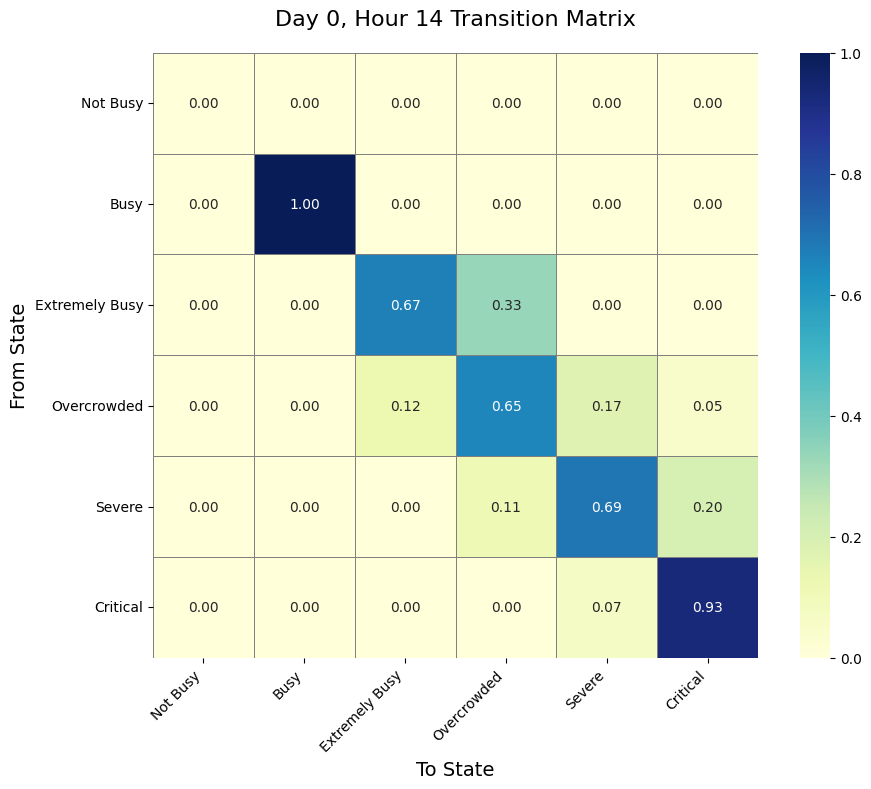

In [ ]:
plot_transition_matrix(transition_matrices_1[0][14], title="Day 0, Hour 14 Transition Matrix")


### One-Year Training Model

A second model was created using the shorter historical period to evaluate
whether the additional observations available to the four-year model improved
forecasting performance.

The same modeling approach is used for both models, including the
day-of-week and hour-of-day transition matrices and chronological
train/test methodology.

Variables ending in `_2` correspond to the one-year model and parallel
the `_1` variables used for the four-year model.

In [ ]:
# Restrict the dataset to the shorter comparison period
start = "2024-01-01"
end = "2025-04-22"
df_filtered = df[(df["timestamp"] >= start) & (df["timestamp"] <= end)]
train_df_2,test_df_2 = split_train_test(df_filtered)

# Generate Transition Matrices based on Train Data
transition_matrices_2 = build_transition_matrices_by_hour_day(train_df_2,states)

# Convert nested dict to flat DataFrame
flat_transition_df_2 = flatten_transition_dict(transition_matrices_2)

#Evaluate Test Split
evaluate_df_2 = evaluate_forecast_on_test_set(test_df_2, flat_transition_df_2, states, 6)

## Model Evaluation

### Overall Forecast Performance

The one-year and four-year models were evaluated across forecast horizons
from one to six hours (t+1 through t+6).

Overall accuracy measures the percentage of forecasts in which the predicted
NEDOCS state matched the observed state. Brier score was also calculated to
evaluate the quality of the model's probabilistic predictions, with lower
scores indicating better probabilistic accuracy.

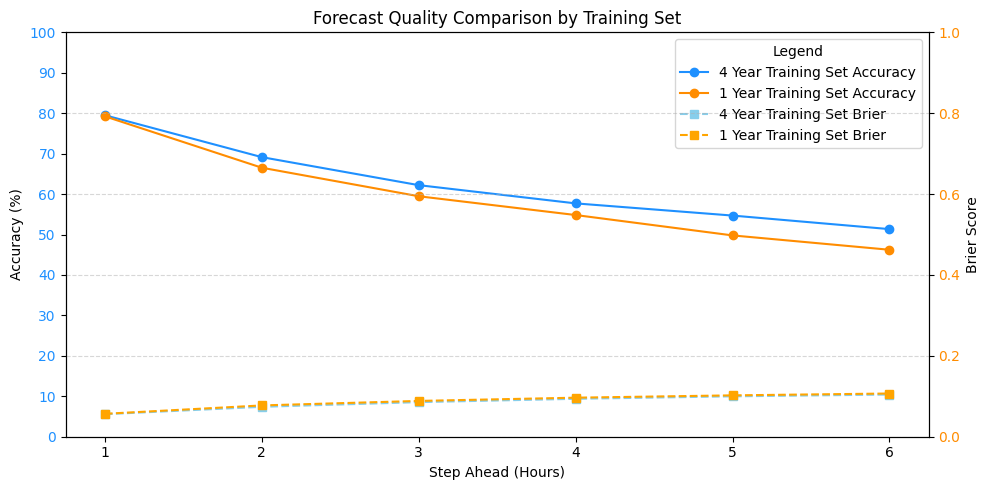

In [ ]:
# Compare forecast performance across training periods

#Four-Year Training Evaluation
score_summary1 = compute_forecast_scores_safe(evaluate_df_1,states)
#One-Year Training Evaluation
score_summary2 = compute_forecast_scores_safe(evaluate_df_2,states)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Top-1 Accuracy for both sets (blue shades)
ax1.plot(score_summary1["step_ahead"], score_summary1["top1_accuracy"] * 100,
         marker='o', color='dodgerblue', label="4 Year Training Set Accuracy")
ax1.plot(score_summary2["step_ahead"], score_summary2["top1_accuracy"] * 100,
         marker='o'
        , color='darkorange', label="1 Year Training Set Accuracy")

ax1.set_ylabel("Accuracy (%)")
ax1.set_ylim(0, 100)
ax1.set_yticks(np.arange(0, 101, 10))
ax1.tick_params(axis='y', labelcolor='dodgerblue')

# Plot Brier Score for both sets (orange shades)
ax2 = ax1.twinx()
ax2.plot(score_summary1["step_ahead"], score_summary1["brier_score"],
         marker='s', color='skyblue', label="4 Year Training Set Brier", linestyle='--')
ax2.plot(score_summary2["step_ahead"], score_summary2["brier_score"],
         marker='s', color='orange', label="1 Year Training Set Brier", linestyle='--')

ax2.set_ylabel("Brier Score")
ax2.set_ylim(0, 1)
ax2.tick_params(axis='y', labelcolor='darkorange')

# Grid and title
plt.title("Forecast Quality Comparison by Training Set")
ax1.set_xlabel("Step Ahead (Hours)")
plt.grid(True, linestyle="--", alpha=0.5)

# Merge legends
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax1.legend(lines, labels, loc="upper right", title="Legend")

plt.tight_layout()
plt.show()


#### Results

Both models achieved approximately 80% accuracy when predicting the NEDOCS
state one hour ahead (t+1). Accuracy declined as the forecast horizon
increased, with the largest decrease occurring between the one- and two-hour
forecast horizons.

The four-year model generally performed slightly better than the one-year
model, suggesting that the additional historical observations provided some
improvement in predictive performance.

Brier scores also increased as the forecast horizon extended, indicating
greater uncertainty in longer-range probabilistic forecasts.

### Forecast Accuracy by NEDOCS State and Training Set

Overall forecast accuracy can mask differences in model performance across
individual NEDOCS states. To examine the effect of training-set length at the
state level, forecast accuracy was compared between the four-year and one-year
models for each NEDOCS state across forecast horizons from t+1 through t+6.

This comparison shows whether the additional historical observations available
to the four-year model improved forecast performance consistently across
crowding states.

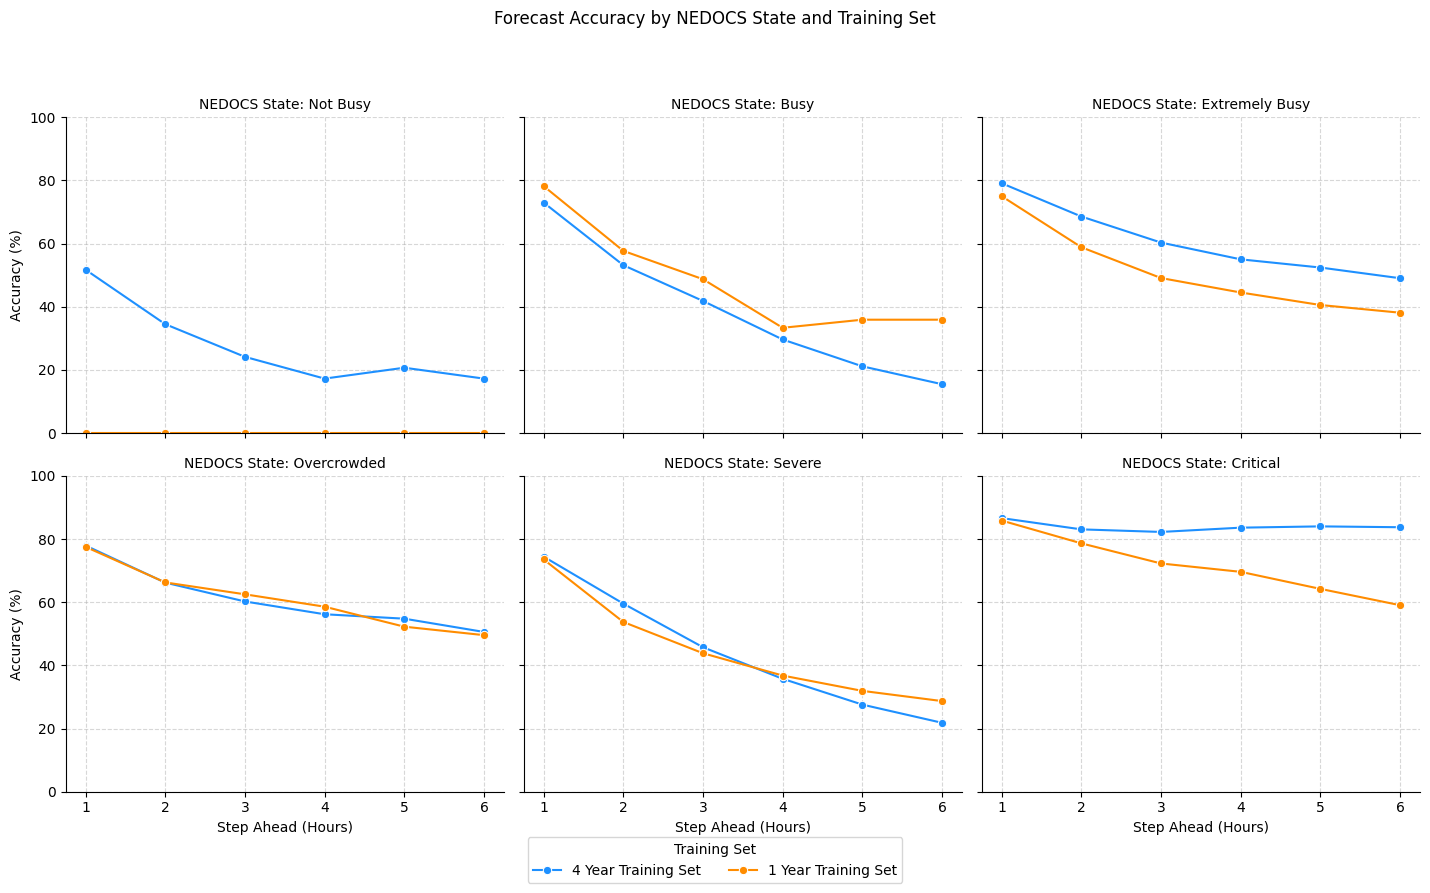

In [ ]:
accuracy_by_state_1 = compute_accuracy_per_state_by_step(evaluate_df_1, states)
accuracy_by_state_2 = compute_accuracy_per_state_by_step(evaluate_df_2, states)

# Add labels
accuracy_by_state_1["source"] = "4 Year Training Set"
accuracy_by_state_2["accuracy"] = accuracy_by_state_2["accuracy"] 
accuracy_by_state_2["source"] = "1 Year Training Set"

# Combine datasets
combined_accuracy_by_state = pd.concat([accuracy_by_state_1, accuracy_by_state_2])
combined_accuracy_by_state["accuracy"] *= 100  # convert to percentage

g = sns.FacetGrid(
    combined_accuracy_by_state,
    col="true_state",
    hue="source",
    col_wrap=3,
    height=4,
    aspect=1.2,
    sharey=True,
    palette={"4 Year Training Set": "dodgerblue", "1 Year Training Set": "darkorange"}
)
g.map(sns.lineplot, "step_ahead", "accuracy", marker="o")
g.set_titles("NEDOCS State: {col_name}")
g.set_axis_labels("Step Ahead (Hours)", "Accuracy (%)")
g.set(ylim=(0, 100))

# Grid lines
for ax in g.axes.flat:
    ax.grid(True, linestyle="--", alpha=0.5)

handles, labels = g.axes.flat[0].get_legend_handles_labels()  # Grab from first subplot
by_label = dict(zip(labels, handles))  # Deduplicate by label

g.fig.legend(
    handles=list(by_label.values()),
    labels=list(by_label.keys()),
    title="Training Set",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    frameon=True
)

# Title and layout
g.fig.suptitle("Forecast Accuracy by NEDOCS State and Training Set", y=1.05)
plt.tight_layout()
plt.show()




#### Results

The effect of the longer training period varied considerably across NEDOCS
states. The largest differences were observed for Not Busy, Extremely Busy,
and Critical. The four-year model achieved measurable accuracy for Not Busy
across all forecast horizons, while the one-year model did not correctly
predict this state during the evaluation period.

For Extremely Busy, the four-year model consistently outperformed the one-year
model, with the difference becoming more pronounced at longer forecast
horizons. Critical showed a similar pattern: both models performed strongly at
t+1, but the four-year model maintained accuracy above 80% through t+6 while
the one-year model declined steadily as the forecast horizon increased.

Performance for Busy, Overcrowded, and Severe was more similar between the two
models, with neither training period consistently outperforming the other
across every forecast horizon. Overall, the results suggest that the additional
historical observations benefited some NEDOCS states substantially more than
others.

### State-Level Forecast Performance by Forecast Horizon

Forecast accuracy was evaluated separately for each NEDOCS state to examine
how model performance changed as the forecast horizon increased. Results are
shown for both the four-year and one-year training models across prediction
horizons from t+1 through t+6.

This analysis provides a within-model view of performance and highlights
differences in predictability among individual crowding states.

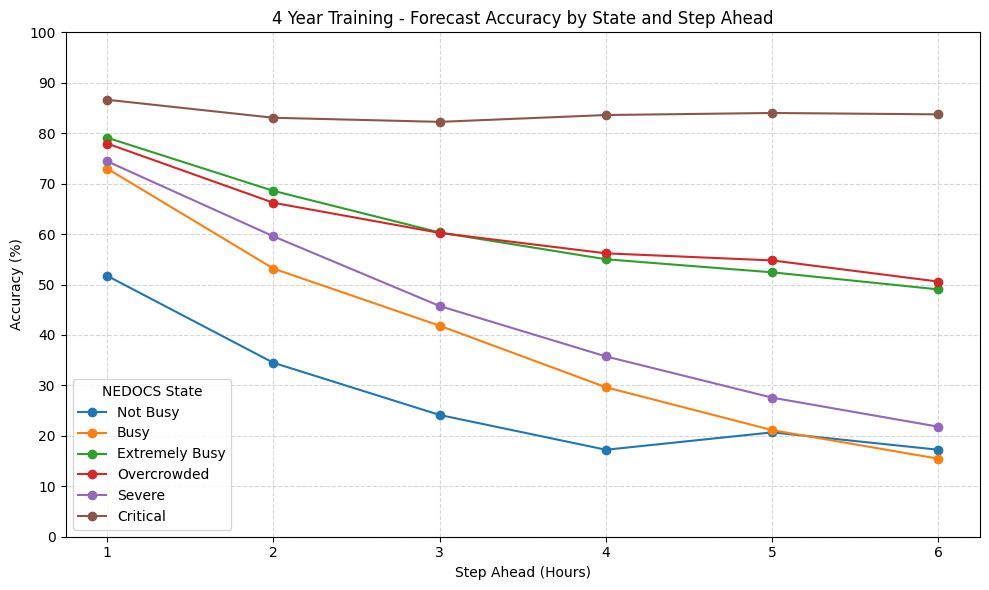

In [ ]:
#Four-Year Training 
# Now compute accuracy per state and plot
accuracy_by_state = compute_accuracy_per_state_by_step(evaluate_df_1, states)

plt.figure(figsize=(10, 6))
for state in states:
    subset = accuracy_by_state[accuracy_by_state["true_state"] == state]
    plt.plot(subset["step_ahead"], subset["accuracy"] * 100, marker='o', label=state)

plt.title("4 Year Training - Forecast Accuracy by State and Step Ahead")
plt.xlabel("Step Ahead (Hours)")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.yticks(np.arange(0, 101, 10))  # Set 10% intervals for ticks
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="NEDOCS State")
plt.tight_layout()
plt.show()

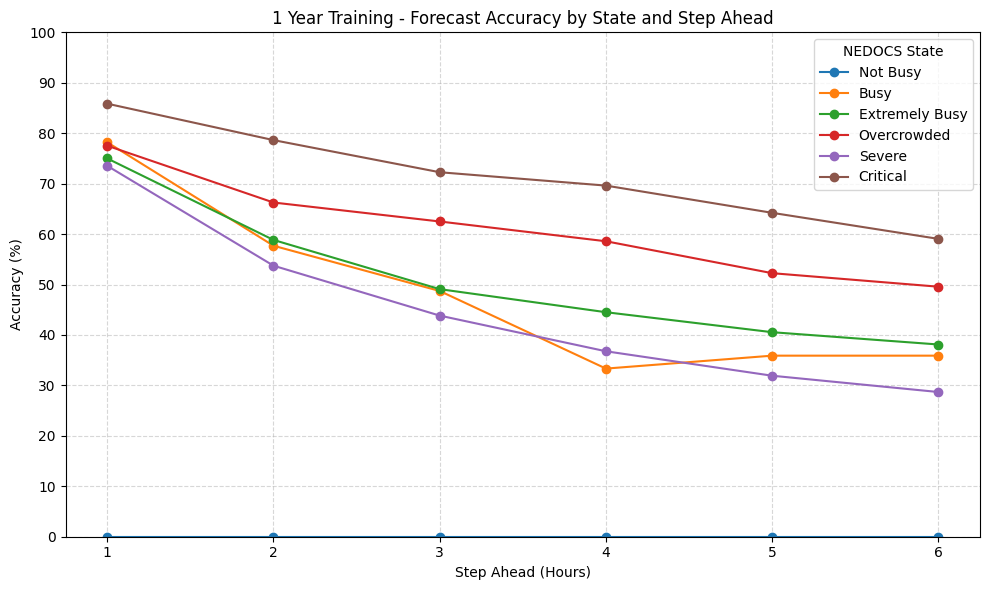

In [ ]:
#One-Year Training 
# Now compute accuracy per state and plot
accuracy_by_state = compute_accuracy_per_state_by_step(evaluate_df_2, states)

plt.figure(figsize=(10, 6))
for state in states:
    subset = accuracy_by_state[accuracy_by_state["true_state"] == state]
    plt.plot(subset["step_ahead"], subset["accuracy"] * 100, marker='o', label=state)

plt.title("1 Year Training - Forecast Accuracy by State and Step Ahead")
plt.xlabel("Step Ahead (Hours)")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.yticks(np.arange(0, 101, 10))  # Set 10% intervals for ticks
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="NEDOCS State")
plt.tight_layout()
plt.show()

#### Results

Both models show substantial differences in forecast accuracy across NEDOCS
states. Critical was the most consistently predicted state in both models,
while accuracy for most other states declined as the forecast horizon
increased.

In the four-year model, Critical remained above 80% accuracy across all six
forecast horizons. Extremely Busy and Overcrowded also retained approximately
50% accuracy at t+6, while Busy, Severe, and Not Busy declined more sharply.

The one-year model showed a similar decline with increasing forecast horizon,
but Critical accuracy decreased from approximately 86% at t+1 to 59% at t+6.
Overcrowded was comparatively stable, remaining near 50% at t+6. Not Busy was
not correctly predicted at any forecast horizon in the one-year evaluation.

Overall, the results show that forecast horizon and NEDOCS state both influence
model performance. Higher accuracy for some states and substantially weaker
performance for others also motivated further examination of the distribution
of NEDOCS states within the training data.

### Classification Performance by NEDOCS State

Normalized confusion matrices were used to examine classification performance
for the four-year and one-year training models at the one-hour (t+1) forecast
horizon. Each row represents the actual NEDOCS state, while the columns show
the percentage of observations assigned to each predicted state.

Values along the diagonal represent correct classifications, while off-diagonal
values show how incorrectly classified observations were distributed across
the other NEDOCS states. This provides additional detail beyond overall
accuracy by showing both how frequently each state was correctly identified
and which states were most commonly confused.

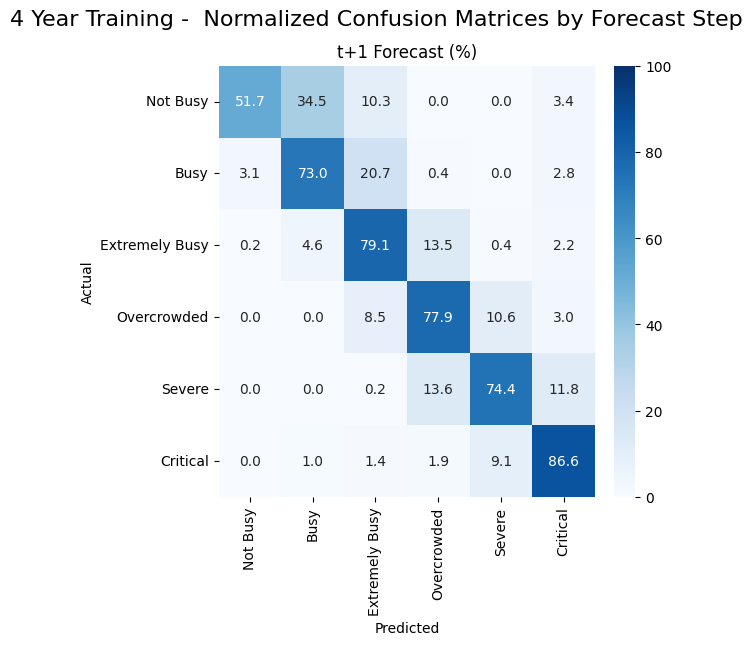

In [ ]:
#Four-Year Training Evaluation
plot_title = "4 Year Training - "
plot_normalized_confusion_matrices_by_step(evaluate_df_1,states,steps=[1],plot_title=plot_title)

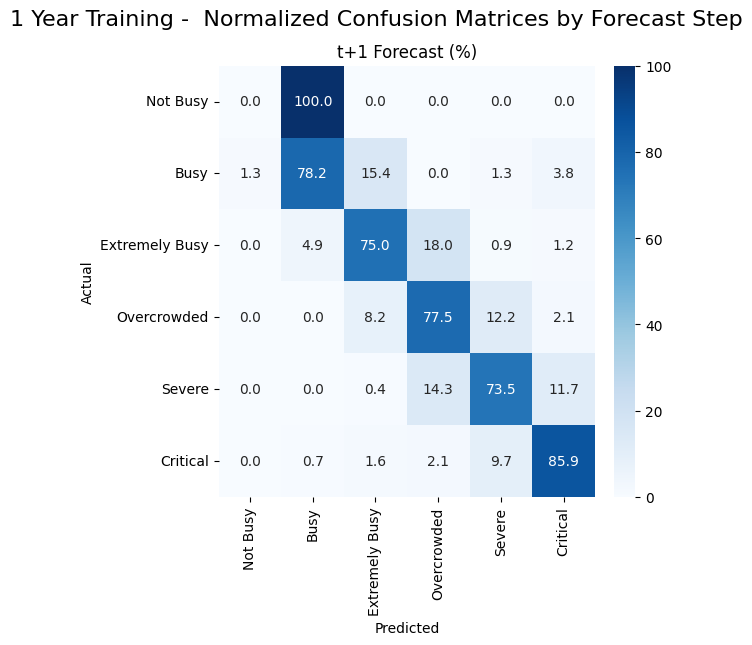

In [ ]:
#One-Year Training Evaluation
plot_title = "1 Year Training - "
plot_normalized_confusion_matrices_by_step(evaluate_df_2,states,steps=[1],plot_title=plot_title)

#### Results

At the one-hour forecast horizon, incorrect predictions were generally
concentrated in neighboring NEDOCS states. For example, Not Busy observations
were most frequently misclassified as Busy, while Extremely Busy observations
were most frequently misclassified as Overcrowded.

This pattern suggests that many forecast errors represented differences in the
estimated degree of crowding rather than predictions at the opposite end of the
NEDOCS scale.

At t+1, the two models produced broadly similar classification patterns for
the more frequently observed NEDOCS states, while the largest difference was
again observed for Not Busy. In the one-year model, all Not Busy observations
were classified as Busy.


### Forecast Accuracy by Day of Week

Forecast performance was also evaluated by day of week to determine whether
the model performed consistently across recurring weekly patterns. Accuracy
was calculated separately for each day across forecast horizons from t+1
through t+6.

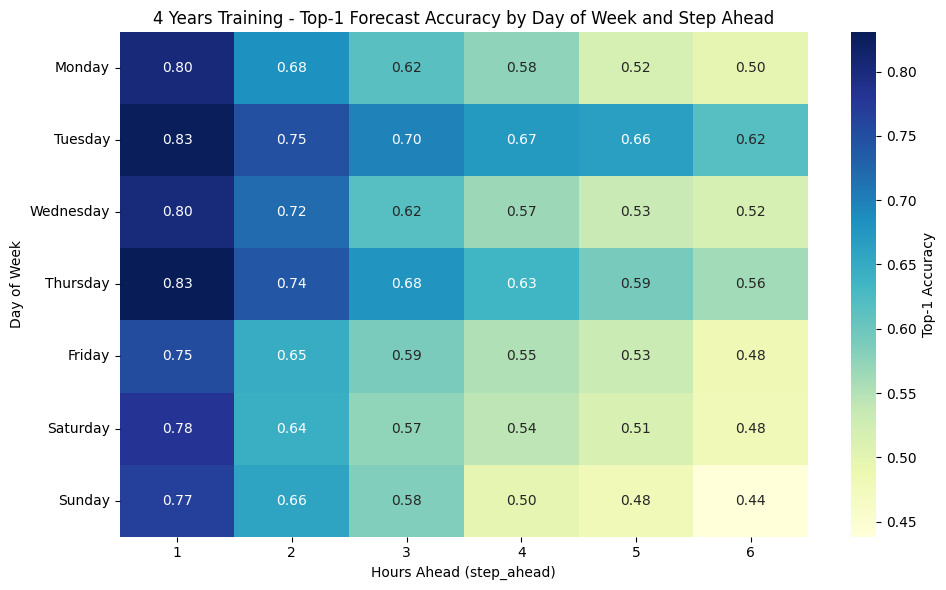

In [434]:
#4 Year Training 80/20
daywise_scores = compute_daywise_forecast_scores(evaluate_df_1, states)

# Pivot for heatmap: Accuracy by day_name and step_ahead

pivot_accuracy = daywise_scores.pivot(index="day_name", columns="step_ahead", values="top1_accuracy").loc[
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
]

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_accuracy, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Top-1 Accuracy'})
plt.title("4 Years Training - Top-1 Forecast Accuracy by Day of Week and Step Ahead")
plt.xlabel("Hours Ahead (step_ahead)")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()



#### Results

Short-term forecast accuracy was relatively consistent across days of the
week, ranging from approximately 75% to 83% at t+1. Differences became more
pronounced as the forecast horizon increased.

Tuesday produced the strongest performance across the longer forecast
horizons, while Sunday generally showed the lowest accuracy. At t+6, accuracy
ranged from approximately 62% on Tuesday to 44% on Sunday.

These results suggest that forecast performance was not uniform across the
week and that some day-specific transition patterns were more predictable
than others.

## Class Distribution and Model Behavior

State-level evaluation revealed substantial differences in forecast performance
across NEDOCS states. To investigate whether the amount of historical data
available for each state may have contributed to these differences, the
training-set distributions were examined for both models.

The figures show both the number of observations and the percentage of the training 
set represented by each NEDOCS state, with summary tables providing the exact class ratios.

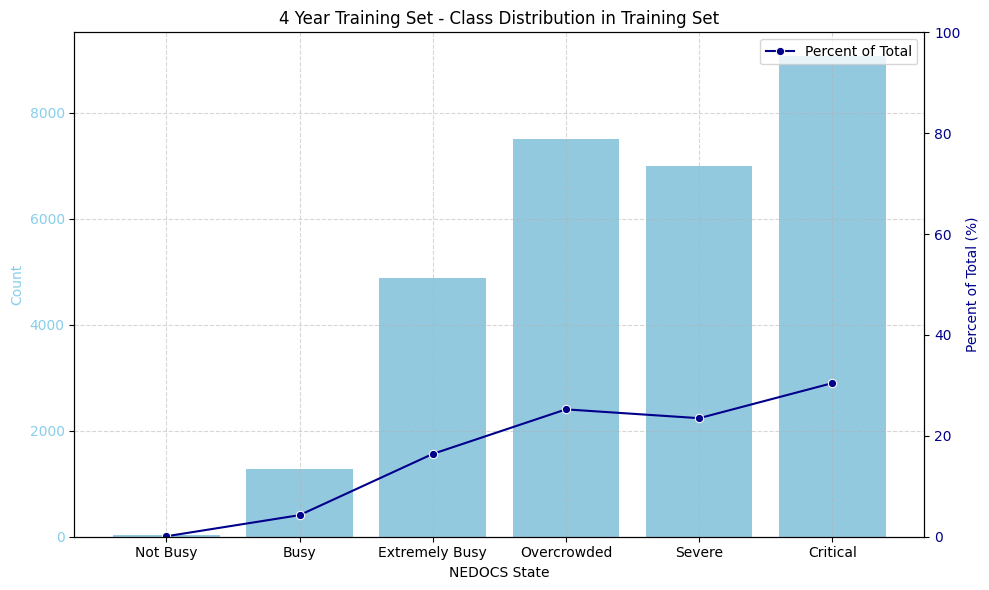

,Count,Percent of Total,Ratio to Most Common,Ratio to Least Common
state,,,,
Not Busy,28,0.09,0.00,1.00
Busy,1273,4.28,0.14,45.46
Extremely Busy,4886,16.42,0.54,174.50
Overcrowded,7512,25.25,0.83,268.29
Severe,6993,23.50,0.77,249.75
Critical,9063,30.46,1.00,323.68


In [ ]:
# Calculate class ratios from the training set
class_counts = train_df_1["state"].value_counts().reindex(states, fill_value=0)
total = class_counts.sum()
class_ratios = (class_counts / total) * 100

# Dynamically identify most and least common classes
most_common_value = class_counts.max()
least_common_value = class_counts[class_counts > 0].min()  # Avoid division by zero

# Compute ratios
ratio_to_most = (class_counts / most_common_value).round(2)
ratio_to_least = (class_counts / least_common_value).round(2)

# Create the summary DataFrame
class_ratio_summary = pd.DataFrame({
    "Count": class_counts,
    "Percent of Total": class_ratios.round(2),
    "Ratio to Most Common": ratio_to_most,
    "Ratio to Least Common": ratio_to_least
})

# Plot a grouped bar chart of the class ratio summary

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for count
sns.barplot(x=class_ratio_summary.index, y=class_ratio_summary["Count"], color="skyblue", ax=ax1)
ax1.set_ylabel("Count", color="skyblue")
ax1.tick_params(axis='y', labelcolor="skyblue")
ax1.set_xlabel("NEDOCS State")

# Add secondary y-axis for percentage
ax2 = ax1.twinx()
sns.lineplot(x=class_ratio_summary.index, y=class_ratio_summary["Percent of Total"], 
             marker="o", color="darkblue", label="Percent of Total", ax=ax2)
ax2.set_ylabel("Percent of Total (%)", color="darkblue")
ax2.tick_params(axis='y', labelcolor="darkblue")
ax2.set_ylim(0, 100)

# Title and layout
plt.title("4 Year Training Set - Class Distribution in Training Set")
ax1.grid(True, linestyle="--", alpha=0.5)
fig.tight_layout()
plt.show()

class_ratio_summary

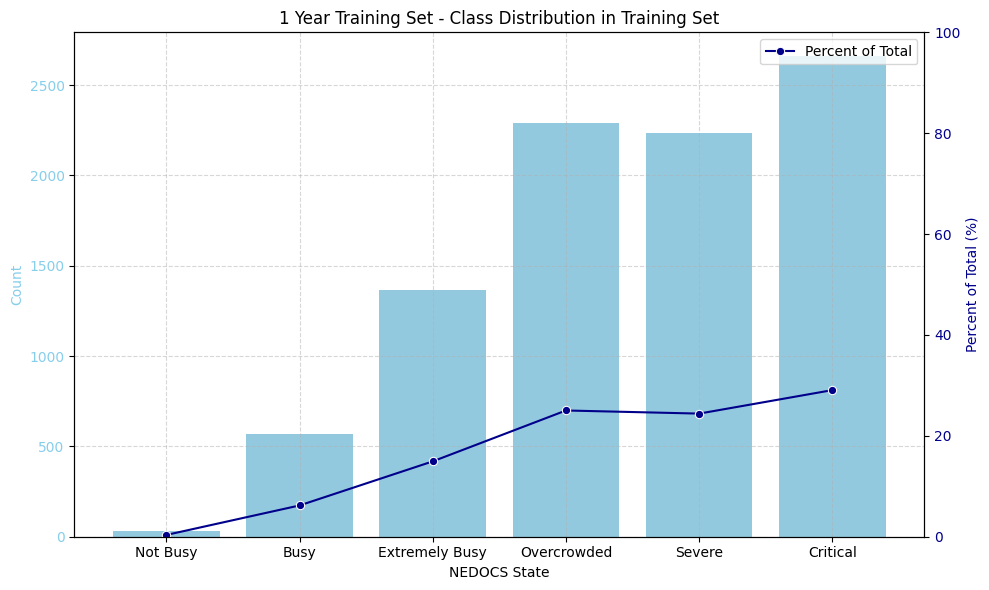

,Count,Percent of Total,Ratio to Most Common,Ratio to Least Common
state,,,,
Not Busy,32,0.35,0.01,1.00
Busy,567,6.20,0.21,17.72
Extremely Busy,1367,14.94,0.51,42.72
Overcrowded,2290,25.03,0.86,71.56
Severe,2233,24.41,0.84,69.78
Critical,2659,29.07,1.00,83.09


In [ ]:
# Calculate class ratios from the training set
class_counts = train_df_2["state"].value_counts().reindex(states, fill_value=0)
total = class_counts.sum()
class_ratios = (class_counts / total) * 100

# Dynamically identify most and least common classes
most_common_value = class_counts.max()
least_common_value = class_counts[class_counts > 0].min()  # Avoid division by zero

# Compute ratios
ratio_to_most = (class_counts / most_common_value).round(2)
ratio_to_least = (class_counts / least_common_value).round(2)

# Create the summary DataFrame
class_ratio_summary = pd.DataFrame({
    "Count": class_counts,
    "Percent of Total": class_ratios.round(2),
    "Ratio to Most Common": ratio_to_most,
    "Ratio to Least Common": ratio_to_least
})



# Plot a grouped bar chart of the class ratio summary

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for count
sns.barplot(x=class_ratio_summary.index, y=class_ratio_summary["Count"], color="skyblue", ax=ax1)
ax1.set_ylabel("Count", color="skyblue")
ax1.tick_params(axis='y', labelcolor="skyblue")
ax1.set_xlabel("NEDOCS State")

# Add secondary y-axis for percentage
ax2 = ax1.twinx()
sns.lineplot(x=class_ratio_summary.index, y=class_ratio_summary["Percent of Total"], 
             marker="o", color="darkblue", label="Percent of Total", ax=ax2)
ax2.set_ylabel("Percent of Total (%)", color="darkblue")
ax2.tick_params(axis='y', labelcolor="darkblue")
ax2.set_ylim(0, 100)

# Title and layout
plt.title("1 Year Training Set - Class Distribution in Training Set")
ax1.grid(True, linestyle="--", alpha=0.5)
fig.tight_layout()
plt.show()

class_ratio_summary

#### Results

Both training sets show substantial class imbalance, with observations
concentrated in the higher NEDOCS states. In the four-year training set,
Critical represents the largest share of observations, followed by
Overcrowded and Severe, while Busy and particularly Not Busy are much
less frequently represented.

The one-year training set shows a similar distribution but contains
substantially fewer observations overall. The limited representation of
Not Busy is particularly notable given that the one-year model did not
correctly predict this state during evaluation.

The larger number of observations available in the four-year training
set may provide more information for estimating transition probabilities,
particularly for less frequently observed state and time combinations.
The distribution also suggests that class imbalance may contribute to
differences in state-level forecast performance, although the observed
relationship does not establish causation.

## Limitations and Future Work

Several limitations should be considered when interpreting these results. The
training data were substantially imbalanced across NEDOCS states, with higher
crowding states occurring much more frequently than lower crowding states.
This was particularly pronounced for the Not Busy state and may have affected
the model's ability to estimate reliable transition probabilities for less
frequently observed states.

The model also estimates transition probabilities separately for each
day-of-week and hour-of-day combination. Although this structure captures
recurring temporal patterns, dividing the observations across 168 temporal
combinations further reduces the amount of data available for some state and
time combinations. This may contribute to unstable estimates when relatively
few historical transitions are available.

Forecast performance also declined as the prediction horizon increased,
indicating that the Markov approach is most useful for shorter-term forecasts.
Because predictions are based primarily on historical state-transition
behavior, the model does not incorporate other operational factors that may
influence emergency department crowding.

Future work could investigate methods for addressing class imbalance and sparse
transition combinations, including alternative weighting or smoothing
approaches. Additional predictors such as patient arrivals, census, staffing,
boarding, or other operational measures could also be incorporated into more
advanced forecasting models. Comparing the Markov approach with other
statistical or machine-learning methods would help determine whether additional
model complexity produces meaningful improvements in forecast performance.

## Conclusion

The results demonstrate that a time-dependent Markov model can provide useful
short-term forecasts of emergency department crowding states using historical
NEDOCS observations. Both models achieved approximately 80% accuracy at the
one-hour forecast horizon, with performance declining as the forecast window
increased.

The longer training period generally produced stronger and more stable
state-level forecasts, suggesting that additional historical observations can
improve estimation of time-dependent transition behavior. At the same time,
substantial class imbalance and sparse observations for lower crowding states
highlight important limitations of the approach.

Overall, the project demonstrates the potential of probabilistic state-transition
models for short-term operational forecasting while identifying opportunities
for future models incorporating additional clinical and operational predictors.